# 02 · Preprocesado — Taller B4-T1 (Fair Credit Model)

**Objetivo.** Convertir `data/application_train.csv` (307.511 filas) en un dataset **limpio, dividido en
train/val/test y reproducible**, listo para modelar y **sin fuga de información**. Este notebook es el
puente entre el diagnóstico (`notebooks/01_EDA.ipynb`) y las cuatro tareas de modelado: toma cada hallazgo
del EDA y lo materializa como una decisión de diseño concreta (`docs/DECISIONES.md`, sección *Preprocesado*).

| Decisión | Qué hace | Estado |
|---|---|---|
| **D-P.1** | Centinela `365243` en `DAYS_EMPLOYED` → `NaN` + flag `DAYS_EMPLOYED_ANOM` | Confirmada |
| **D-P.2** | Flags `*_missing` **antes** de imputar + imputación parametrizable (mediana base) | Revisar |
| **D-P.3** | `log1p` sobre `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY` | Confirmada |
| **D-P.4** | Descartar las 4 filas `XNA` de `CODE_GENDER` | Confirmada |
| **D-P.5** | Winsorizar la cola alta de `AMT_INCOME_TOTAL` a p99,9 (calculado en train) | Confirmada |
| **D-P.6** | Split estratificado **antes** de imputar/escalar; parámetros solo de train | Confirmada |

**Principio rector (anti-fuga, D-P.6).** Lo *determinista por fila* (descartar XNA, centinela→NaN,
flags, `log1p`) va **antes** del split. Lo que *aprende estadísticos* (p99,9, medianas, media/std)
vive en un objeto `fit(train) → transform(val/test)`: validación y test son **físicamente invisibles**
en el `fit`. Por eso el notebook está ordenado **limpieza determinista → split → fit solo en train**.

**Qué prepara este preprocesado para cada tarea.**

- **Tarea 1 (capa custom, ratio de endeudamiento).** Deja las financieras `AMT_INCOME_TOTAL`,
  `AMT_CREDIT` y `AMT_ANNUITY` ya winsorizadas/logueadas/escaladas, de modo que la capa con exponente
  entrenable `x^p` reciba inputs con la cola domada (el DTI lo construye esa capa, no este notebook).
- **Tarea 2 (FAIR loss).** Reserva `CODE_GENDER` como columna **`S`** (M=1/F=0), **fuera** de la matriz
  de features `X`: solo se usará en la loss de equidad durante el entrenamiento, nunca como input de predicción.
- **Tarea 3 (Keras Tuner).** Produce un corte de **validación** independiente para que el tuner elija la
  topología sin tocar el test, reservado a la evaluación final imparcial.
- **Tarea 4 (incertidumbre).** Conserva los flags `*_missing` y `N_EXT_MISSING` (0–3), la materia prima
  para cruzar la varianza epistémica `Var[p]` con la calidad de información externa por solicitante.

## Bloque 0 — Setup

Imports, semilla `RNG=42`, rutas **relativas** (`../data/`), creación de `data/processed/`,
paleta semántica del EDA (azul = paga, rojo = impaga) y las columnas del taller.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reproducibilidad ---
RNG = 42
np.random.seed(RNG)

# --- Rutas relativas (nada absoluto) ---
DATA_DIR = Path("../data")
PROC_DIR = DATA_DIR / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

# --- Paleta semántica coherente con el EDA ---
COLOR_PAGA = "#2c7fb8"    # azul   = paga  (TARGET = 0)
COLOR_IMPAGA = "#d7301f"  # rojo   = impaga (TARGET = 1)
COLOR_ACENTO = "#41ab5d"  # verde  = series neutras / referencias (no semánticas)
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

# --- Columnas del taller ---
TARGET = "TARGET"
SENSITIVE = "CODE_GENDER"                                    # S de la Tarea 2 (FAIR loss)
COLS_FIN_LOG = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]  # cola larga -> log1p (D-P.3)
COLS_EXT = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
COL_DAYS = "DAYS_EMPLOYED"
COL_BIRTH = "DAYS_BIRTH"          # edad (alineacion con el esqueleto del profe; D-P.7)
# Continuas que pasan por el pipeline (winsor/log/imputa/escala):
# DAYS_BIRTH solo se imputa (no tiene nulos -> no-op) y se escala; NO se winsoriza ni se loguea.
CONT_COLS = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
             "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "DAYS_EMPLOYED", "DAYS_BIRTH"]

USECOLS = [TARGET, SENSITIVE] + CONT_COLS
df = pd.read_csv(DATA_DIR / "application_train.csv", usecols=USECOLS)
print("Dimensiones brutas:", df.shape)
print("Tasa de impago bruta:", f"{df[TARGET].mean()*100:.2f}%")
df.head()

Dimensiones brutas: (307511, 10)
Tasa de impago bruta: 8.07%


,TARGET,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,1,M,202500.0,406597.5,24700.5,-9461,-637,0.083037,0.262949,0.139376
1,0,F,270000.0,1293502.5,35698.5,-16765,-1188,0.311267,0.622246,NaN
2,0,M,67500.0,135000.0,6750.0,-19046,-225,NaN,0.555912,0.729567
3,0,F,135000.0,312682.5,29686.5,-19005,-3039,NaN,0.650442,NaN
4,0,M,121500.0,513000.0,21865.5,-19932,-3038,NaN,0.322738,NaN


## Bloque 1 — Limpieza PRE-split (determinista, NO aprende parámetros)

Todo lo de este bloque es **fila a fila** y no usa estadísticos del conjunto, así que es seguro
hacerlo antes del split (no hay fuga posible). Aquí materializamos D-P.4, D-P.1 y la **parte fija**
de D-P.2 (los flags de ausencia, que deben existir *antes* de imputar).

In [2]:
# --- D-P.4 · Descartar XNA en CODE_GENDER (4 filas, 0,0013 %) ---
n0 = len(df)
df = df[df[SENSITIVE].isin(["F", "M"])].copy()
n_xna = n0 - len(df)
# Codificar genero a binario, conservandolo como COLUMNA (S de la Tarea 2; nunca entra en X de prediccion)
df[SENSITIVE] = (df[SENSITIVE] == "M").astype(int)   # M=1, F=0
print(f"D-P.4 · XNA descartadas: {n_xna} filas ({100*n_xna/n0:.4f} %) -> quedan {len(df)}")
print("        CODE_GENDER ahora binaria:", sorted(df[SENSITIVE].unique()))

# --- D-P.1 · Centinela 365243 en DAYS_EMPLOYED -> flag + NaN ---
mask_anom = df[COL_DAYS] == 365243
n_anom = int(mask_anom.sum())
df["DAYS_EMPLOYED_ANOM"] = mask_anom.astype(int)      # flag binario (lleva senal: pensionistas)
df.loc[mask_anom, COL_DAYS] = np.nan                  # el centinela pasa a NaN (lo imputa el pipeline)

# --- D-P.7 (alineacion con el esqueleto del profe) -> DAYS_BIRTH a edad en anos positivos ---
# Determinista por fila (no aprende parametros): se puede hacer antes del split sin fuga.
df[COL_BIRTH] = df[COL_BIRTH].abs() / 365
print(f"D-P.7 - DAYS_BIRTH -> edad: min {df[COL_BIRTH].min():.1f}  max {df[COL_BIRTH].max():.1f}  anos "
      f"(skew {df[COL_BIRTH].skew():.2f}; sin log: acotada y simetrica)")
print(f"D-P.1 · centinela 365243 -> NaN: {n_anom} filas ({100*n_anom/len(df):.2f} %)")

# --- D-P.2 (parte fija) · Flags de ausencia EXT_SOURCE ANTES de imputar ---
for c in COLS_EXT:
    df[f"{c}_missing"] = df[c].isna().astype(int)
df["N_EXT_MISSING"] = df[[f"{c}_missing" for c in COLS_EXT]].sum(axis=1)   # conteo 0-3 (ordinal)
print("D-P.2 · % nulos por fuente:",
      {c: round(df[f'{c}_missing'].mean()*100, 1) for c in COLS_EXT})
print("D-P.2 · distribucion N_EXT_MISSING:\n",
      df["N_EXT_MISSING"].value_counts().sort_index().to_string())

# Columnas binarias/ordinales que NO se escalan ni transforman
FLAG_COLS = [f"{c}_missing" for c in COLS_EXT] + ["N_EXT_MISSING", "DAYS_EMPLOYED_ANOM"]
print("\nFlags (sin escalar):", FLAG_COLS)

D-P.4 · XNA descartadas: 4 filas (0.0013 %) -> quedan 307507
        CODE_GENDER ahora binaria: [np.int64(0), np.int64(1)]


D-P.7 - DAYS_BIRTH -> edad: min 20.5  max 69.1  anos (skew 0.12; sin log: acotada y simetrica)
D-P.1 · centinela 365243 -> NaN: 55374 filas (18.01 %)
D-P.2 · % nulos por fuente: {'EXT_SOURCE_1': np.float64(56.4), 'EXT_SOURCE_2': np.float64(0.2), 'EXT_SOURCE_3': np.float64(19.8)}
D-P.2 · distribucion N_EXT_MISSING:
 N_EXT_MISSING
0    109587
1    161011
2     36737
3       172

Flags (sin escalar): ['EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing', 'N_EXT_MISSING', 'DAYS_EMPLOYED_ANOM']


**Decisiones aplicadas en este bloque.**

- **D-P.4 (Confirmada).** Se descartan las **4 filas `XNA`** (0,0013 % de 307.511, según el EDA):
  volumen irrelevante y necesarias de quitar para tener un `CODE_GENDER` **binario limpio**, que es
  lo que asume la FAIR loss de la Tarea 2. Se codifica M=1 / F=0 y se **conserva como columna**
  (es `S`, variable sensible: se usa solo en entrenamiento de la loss, **nunca** como input de predicción).
- **D-P.1 (Confirmada).** El centinela `365243` (≈1.000 años) afecta a **55.374 filas (18,01 %)**, casi
  todos pensionistas, y ese grupo **impaga menos (5,40 % vs 8,66 %)**: la información tiene señal. Se
  separa esa señal en el flag `DAYS_EMPLOYED_ANOM` y el valor crudo pasa a `NaN` (si se dejara, destrozaría
  cualquier escala/log).
- **D-P.2 — parte fija (Revisar).** Los flags `*_missing` se crean **antes de imputar** porque la imputación
  borraría la información de "dato ausente". El EDA mide nulos **56,4 % / 19,8 % / 0,2 %** y muestra que la
  ausencia **predice impago** (0→7,3 %, 1→8,2 %, 2→9,9 %). Como las tres fuentes **no faltan juntas**
  (correlación de flags ≈ 0), `N_EXT_MISSING` es un **gradiente real** y no redundante (insumo de D-4.3).

- **D-P.7 (alineación con el profe).** Añadimos **`DAYS_BIRTH` transformada a edad (`abs/365`)**, igual que `load_home_credit_data` del esqueleto del profe. El EDA confirma que es un **predictor legítimo** (corr **−0,078** con `TARGET`, por encima de las financieras crudas) y que está **acotada (20,5–69,1 años) y es casi simétrica (skew 0,12)**: por eso usamos `abs/365` y **no `log1p`** (loguear una variable ya bien condicionada la distorsionaría). Es determinista por fila, así que se calcula antes del split; el escalado, en cambio, se ajusta solo en train (D-P.6). Mantenemos además `DAYS_EMPLOYED` + su flag de centinela (D-P.1): la inclusión de la edad es **aditiva**, no la sustituye.

## Bloque 2 — Split estratificado 3 vías (D-P.6)

Con la limpieza **determinista** ya hecha (Bloque 1), llega el momento bisagra del anti-fuga: **dividir
antes de aprender nada**. A partir de esta celda, val y test quedan apartados y **ningún estadístico**
(percentiles, medianas, media/std del Bloque 3) podrá calcularse mirándolos.

Doble `train_test_split` **estratificado por `TARGET`** (70 / 15 / 15). La validación servirá para que
Keras Tuner (Tarea 3) elija topología sin tocar el test, reservado a la evaluación final imparcial.
En cada corte separamos `X` (features de predicción), `S` (`CODE_GENDER`, solo entrenamiento) e `y` (`TARGET`).

In [3]:
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15   # proporciones parametrizadas

feature_cols = CONT_COLS + FLAG_COLS                  # X de prediccion (continuas + flags); S y TARGET fuera
X_all = df[feature_cols]
S_all = df[SENSITIVE]
y_all = df[TARGET]

# Split 1: train vs temp (estratificado por TARGET)
X_train, X_temp, S_train, S_temp, y_train, y_temp = train_test_split(
    X_all, S_all, y_all,
    test_size=(VAL_SIZE + TEST_SIZE), stratify=y_all, random_state=RNG)

# Split 2: temp -> val / test (estratificado por TARGET)
rel = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
X_val, X_test, S_val, S_test, y_val, y_test = train_test_split(
    X_temp, S_temp, y_temp,
    test_size=rel, stratify=y_temp, random_state=RNG)

default_rates = {}
print(f"{'corte':<6}{'n':>9}{'impago %':>11}")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    r = float(y.mean())
    default_rates[name] = r
    print(f"{name:<6}{len(y):>9}{r*100:>10.2f}%")
print(f"{'TOTAL':<6}{len(y_all):>9}{y_all.mean()*100:>10.2f}%")

corte         n   impago %
train    215254      8.07%
val       46126      8.07%
test      46127      8.07%
TOTAL    307507      8.07%


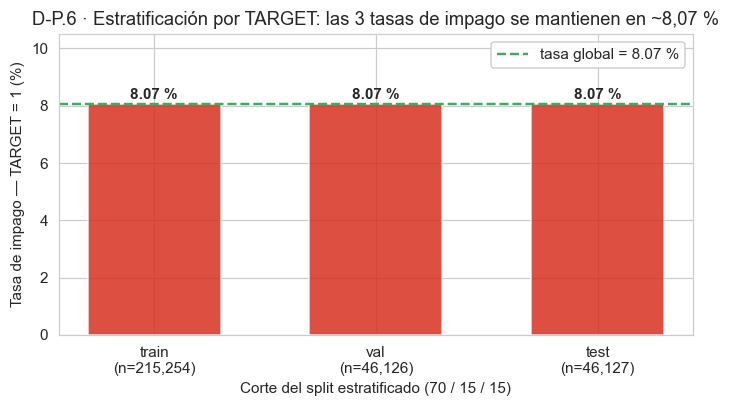

In [4]:
# Verificacion visual de la estratificacion: el % de impago debe rondar el 8,07 % del EDA en los 3 cortes
fig, ax = plt.subplots(figsize=(6.5, 3.8))
cortes = list(default_rates.keys())
vals = [default_rates[c] * 100 for c in cortes]
etiquetas = [f"{c}\n(n={len(y):,})" for c, y in
             zip(cortes, [y_train, y_val, y_test])]

barras = ax.bar(etiquetas, vals, color=COLOR_IMPAGA, alpha=0.85,
                edgecolor="white", width=0.6)
global_rate = y_all.mean() * 100
ax.axhline(global_rate, color=COLOR_ACENTO, ls="--", lw=1.6,
           label=f"tasa global = {global_rate:.2f} %")
for rect, v in zip(barras, vals):
    ax.text(rect.get_x() + rect.get_width() / 2, v + 0.07, f"{v:.2f} %",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Tasa de impago — TARGET = 1 (%)")
ax.set_xlabel("Corte del split estratificado (70 / 15 / 15)")
ax.set_title("D-P.6 · Estratificación por TARGET: las 3 tasas de impago se mantienen en ~8,07 %")
ax.set_ylim(0, max(vals) * 1.30)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

**D-P.6 (Confirmada).** El split va **antes** de imputar/escalar/winsorizar. La estratificación por
`TARGET` protege el **8,07 % de positivos** (desbalance 11,4:1 del EDA): las tres tasas de impago quedan
prácticamente clavadas en ~8,07 %, confirmando que la partición no sesga la clase minoritaria. A partir de
aquí, **cualquier parámetro se aprende solo de `X_train`**.

## Bloque 3 — Transformaciones que APRENDEN parámetros (`fit` SOLO en train)

Aquí vive todo lo que mira estadísticos del conjunto. Lo encapsulamos en un `Pipeline` de sklearn con
transformers a medida que **preservan el DataFrame** (mantienen nombres de columna y dejan intactos los
flags y `S`/`TARGET`). El `fit` se hace **solo con `X_train`**; `val` y `test` solo reciben `transform`.

Orden (importa): **winsorizar ingreso → `log1p` → imputar → escalar**.

In [5]:
class WinsorizerHigh(BaseEstimator, TransformerMixin):
    '''D-P.5 · recorta SOLO la cola alta de columnas a un percentil aprendido en fit (train).'''
    def __init__(self, columns, quantile=0.999):
        self.columns = columns
        self.quantile = quantile
    def fit(self, X, y=None):
        self.upper_ = {c: float(X[c].quantile(self.quantile)) for c in self.columns}
        return self
    def transform(self, X):
        X = X.copy()
        for c in self.columns:
            X[c] = X[c].clip(upper=self.upper_[c])   # solo cola alta
        return X


class Log1pColumns(BaseEstimator, TransformerMixin):
    '''D-P.3 · log1p (stateless) sobre columnas de cola larga.'''
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        for c in self.columns:
            X[c] = np.log1p(X[c])
        return X


class DFImputer(BaseEstimator, TransformerMixin):
    '''D-P.2 · imputacion PARAMETRIZABLE (mediana por defecto; enchufable a KNN/Iterative sin reescribir).'''
    def __init__(self, columns, imputer=None):
        self.columns = columns
        self.imputer = imputer
    def fit(self, X, y=None):
        from sklearn.base import clone
        base = self.imputer if self.imputer is not None else SimpleImputer(strategy="median")
        self.imputer_ = clone(base)
        self.imputer_.fit(X[self.columns])
        return self
    def transform(self, X):
        X = X.copy()
        X[self.columns] = self.imputer_.transform(X[self.columns])
        return X


class DFScaler(BaseEstimator, TransformerMixin):
    '''Escalado de continuas; NO toca flags binarios ni S/TARGET.'''
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        self.scaler_ = StandardScaler().fit(X[self.columns])
        return self
    def transform(self, X):
        X = X.copy()
        X[self.columns] = self.scaler_.transform(X[self.columns])
        return X


# D-P.2 en Revisar: el imputador base es la MEDIANA, pero queda enchufable.
# Para probar una alternativa, basta cambiar esta linea (la comparacion final mediana vs KNN/Iterative
# se decide por AUC en VALIDACION, no aqui), p.ej.:
#   from sklearn.impute import KNNImputer; IMPUTER = KNNImputer(n_neighbors=5)
IMPUTER = SimpleImputer(strategy="median")

preprocessor = Pipeline(steps=[
    ("winsor", WinsorizerHigh(columns=["AMT_INCOME_TOTAL"], quantile=0.999)),  # D-P.5 (antes de log)
    ("log1p",  Log1pColumns(columns=COLS_FIN_LOG)),                            # D-P.3
    ("impute", DFImputer(columns=CONT_COLS, imputer=IMPUTER)),                 # D-P.2 (resto)
    ("scale",  DFScaler(columns=CONT_COLS)),                                   # escalado continuas
])
preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('winsor', ...), ('log1p', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['AMT_INCOME_TOTAL']
,quantile,0.999
,columns,"['AMT_INCOME_TOTAL', 'AMT_CREDIT', ...]"
,columns,"['AMT_INCOME_TOTAL', 'AMT_CREDIT', ...]"
,imputer,SimpleImputer...tegy='median')
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'


In [6]:
# FIT SOLO EN TRAIN -> transform en los tres cortes (val/test invisibles en el fit)
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

# Parametros aprendidos (todos de train)
p999 = preprocessor.named_steps["winsor"].upper_["AMT_INCOME_TOTAL"]
medians = dict(zip(CONT_COLS, preprocessor.named_steps["impute"].imputer_.statistics_))
print(f"D-P.5 · p99,9 ingreso (solo train, escala bruta): {p999:,.0f}")
print("D-P.2 · medianas de imputacion (post-winsor/log1p, solo train):")
for k, v in medians.items():
    print(f"        {k:<18} {v:.4f}")

print("\nNaN tras transform (deben ser 0 en las continuas):",
      "train", int(X_train_t[CONT_COLS].isna().sum().sum()),
      "| val", int(X_val_t[CONT_COLS].isna().sum().sum()),
      "| test", int(X_test_t[CONT_COLS].isna().sum().sum()))
X_train_t[CONT_COLS].describe().T[["mean", "std", "min", "max"]].round(3)

D-P.5 · p99,9 ingreso (solo train, escala bruta): 900,000
D-P.2 · medianas de imputacion (post-winsor/log1p, solo train):
        AMT_INCOME_TOTAL   11.9028
        AMT_CREDIT         13.1491
        AMT_ANNUITY        10.1228
        EXT_SOURCE_1       0.5062
        EXT_SOURCE_2       0.5664
        EXT_SOURCE_3       0.5353
        DAYS_EMPLOYED      -1645.0000
        DAYS_BIRTH         43.1507

NaN tras transform (deben ser 0 en las continuas): train 0 | val 0 | test 0


,mean,std,min,max
AMT_INCOME_TOTAL,-0.0,1.0,-3.606,3.695
AMT_CREDIT,-0.0,1.0,-3.288,2.994
AMT_ANNUITY,0.0,1.0,-4.902,4.378
EXT_SOURCE_1,-0.0,1.0,-3.516,3.288
EXT_SOURCE_2,-0.0,1.0,-2.696,1.783
EXT_SOURCE_3,0.0,1.0,-2.945,2.177
DAYS_EMPLOYED,0.0,1.0,-7.329,1.052
DAYS_BIRTH,0.0,1.0,-1.959,2.108


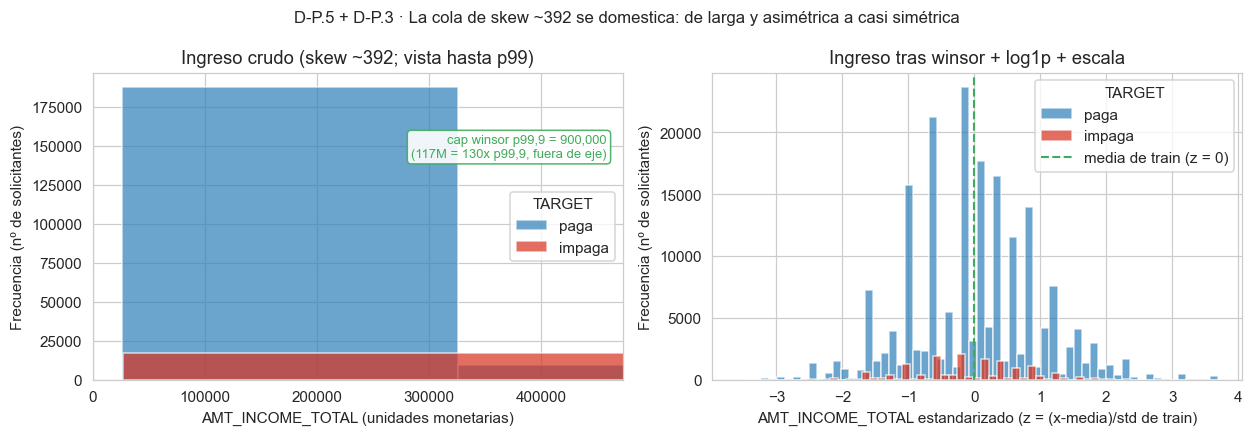

In [7]:
# Verificacion: ingreso ANTES vs DESPUES del pipeline (solo train). Azul = paga / rojo = impaga.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

# --- Izquierda: crudo (vista al p99 para domar la cola; el cap real esta mas a la derecha) ---
raw = X_train["AMT_INCOME_TOTAL"]
axes[0].hist(raw[y_train == 0], bins=60, color=COLOR_PAGA, alpha=0.7, label="paga")
axes[0].hist(raw[y_train == 1], bins=60, color=COLOR_IMPAGA, alpha=0.7, label="impaga")
axes[0].set_xlim(0, raw.quantile(0.99))
axes[0].set_title("Ingreso crudo (skew ~392; vista hasta p99)")
axes[0].set_xlabel("AMT_INCOME_TOTAL (unidades monetarias)")
axes[0].set_ylabel("Frecuencia (nº de solicitantes)")
axes[0].legend(title="TARGET")
axes[0].annotate(f"cap winsor p99,9 = {p999:,.0f}\n(117M = 130x p99,9, fuera de eje)",
                 xy=(0.97, 0.80), xycoords="axes fraction", ha="right", va="top",
                 fontsize=8.5, color=COLOR_ACENTO,
                 bbox=dict(boxstyle="round", fc="white", ec=COLOR_ACENTO, alpha=0.9))

# --- Derecha: tras winsor (p99,9) + log1p + escalado estandar ---
tr = X_train_t["AMT_INCOME_TOTAL"]
axes[1].hist(tr[y_train == 0], bins=60, color=COLOR_PAGA, alpha=0.7, label="paga")
axes[1].hist(tr[y_train == 1], bins=60, color=COLOR_IMPAGA, alpha=0.7, label="impaga")
axes[1].set_title("Ingreso tras winsor + log1p + escala")
axes[1].set_xlabel("AMT_INCOME_TOTAL estandarizado (z = (x-media)/std de train)")
axes[1].set_ylabel("Frecuencia (nº de solicitantes)")
axes[1].axvline(0, color=COLOR_ACENTO, ls="--", lw=1.4, label="media de train (z = 0)")
axes[1].legend(title="TARGET")

fig.suptitle("D-P.5 + D-P.3 · La cola de skew ~392 se domestica: de larga y asimétrica a casi simétrica",
             fontsize=11)
plt.tight_layout()
plt.show()

**Decisiones aplicadas en este bloque (todas con `fit` solo en train).**

- **D-P.5 (Confirmada).** Winsorización de la **cola alta** de `AMT_INCOME_TOTAL` a **p99,9 calculado solo
  en train**. El EDA detecta `117.000.000` como caso único = **130× el p99,9** (solo 3 filas > 10M); recortar
  la cola evita que un valor absurdo domine la escala. **Va antes de `log1p`**: loguear primero falsearía el
  percentil.
- **D-P.3 (Confirmada).** `log1p` (no `log`, para tolerar ceros) sobre `AMT_INCOME_TOTAL`, `AMT_CREDIT`,
  `AMT_ANNUITY`, las tres de cola larga (skews EDA **391,6 / 1,2 / 1,6**). Es `log1p` **stateless**, sin
  parámetros que aprender.
- **D-P.2 — resto (Revisar).** `SimpleImputer(strategy="median")` ajustado **solo en train** sobre las 8
  continuas: rellena `EXT_SOURCE_1/2/3`, `AMT_ANNUITY` (**12 nulos** en EDA) y el `DAYS_EMPLOYED` que dejó el
  centinela (`DAYS_BIRTH` no tiene nulos, así que su imputación es un no-op). El imputador está
  **parametrizado** (`IMPUTER`): cambiar a KNN/Iterative no requiere reescribir el pipeline. La elección
  definitiva (mediana vs alternativa) se decidirá **por AUC en validación**, no aquí.
- **Escalado.** `StandardScaler` (media/std de train) sobre las 8 continuas. **No** se escalan los flags
  binarios (`*_missing`, `DAYS_EMPLOYED_ANOM`) ni `N_EXT_MISSING` (conteo ordinal 0–3, interpretable y ya
  acotado), ni `CODE_GENDER`/`TARGET`.

> **Anti-fuga.** Aprenden de train: **p99,9**, **medianas**, **media/std**. No aprenden (pre-split / stateless):
> descartar XNA, centinela→NaN, flags, `log1p`. El ratio de endeudamiento (DTI) **no** se fabrica aquí: lo
> construye la capa custom de la Tarea 1.

## Bloque 4 — Ensamblado y guardado

Con las continuas ya transformadas (Bloque 3) y los flags intactos desde el Bloque 1, solo queda
**recomponer** cada corte y persistirlo para que las cuatro tareas partan exactamente del mismo punto.

Reconstruimos cada corte (continuas transformadas + flags + `CODE_GENDER` + `TARGET`) y persistimos a
`data/processed/` (fuera de git por `.gitignore: data/*`). `pyarrow` está disponible, así que usamos
**parquet** (preserva dtypes). Guardamos también el `preprocessor` con joblib y un `metadata.json`, de modo
que cualquiera pueda recargar el mismo `transform` y reproducir el dataset sin reejecutar este notebook.

> **Caveat al recargar `preprocessor.joblib`.** El pipeline contiene transformers a medida
> (`WinsorizerHigh`, `Log1pColumns`, `DFImputer`, `DFScaler`). joblib serializa estos objetos **por
> referencia a su clase**, no su código fuente, así que `joblib.load(...)` solo funciona si esas clases
> están **definidas/importables en el entorno** donde se recarga (p. ej. reejecutando las celdas del
> Bloque 3, o moviéndolas a un módulo `.py` e importándolas). En un proceso limpio sin ellas la carga
> falla con `AttributeError: Can't get attribute 'WinsorizerHigh'`. Los `.parquet`, en cambio, se cargan
> sin ninguna dependencia de estas clases.

In [8]:
def assemble(Xt, S, y):
    out = Xt.copy()
    out[SENSITIVE] = S.values   # columna sensible (S), conservada pero fuera de X de prediccion
    out[TARGET] = y.values
    return out

train_df = assemble(X_train_t, S_train, y_train)
val_df   = assemble(X_val_t,   S_val,   y_val)
test_df  = assemble(X_test_t,  S_test,  y_test)

# Eleccion de formato: parquet si hay pyarrow/fastparquet, si no CSV de respaldo
try:
    import pyarrow  # noqa: F401
    fmt = "parquet"
except ImportError:
    fmt = "csv"

paths = {}
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    p = PROC_DIR / f"{name}.{fmt}"
    (d.to_parquet(p, index=False) if fmt == "parquet" else d.to_csv(p, index=False))
    paths[name] = str(p)

joblib.dump(preprocessor, PROC_DIR / "preprocessor.joblib")

metadata = {
    "seed": RNG,
    "split_proportions": {"train": TRAIN_SIZE, "val": VAL_SIZE, "test": TEST_SIZE},
    "default_rates": {k: round(v, 6) for k, v in default_rates.items()},
    "format": fmt,
    "columns": {
        "features_X": CONT_COLS + FLAG_COLS,   # X exacta (sin genero ni target) -> contrato (X, y, s)
        "features_continuas": CONT_COLS,
        "flags": FLAG_COLS,
        "sensible": SENSITIVE,
        "target": TARGET,
    },
    "learned_params": {
        "income_p999_train": float(p999),
        "medianas_train": {k: float(v) for k, v in medians.items()},
    },
    "imputer": type(IMPUTER).__name__,
}
(PROC_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Formato de guardado: {fmt}  (pyarrow disponible: {fmt == 'parquet'})")
for name in ["train", "val", "test"]:
    print(f"  {name}: {paths[name]}")
print("  preprocessor:", PROC_DIR / "preprocessor.joblib")
print("  metadata:", PROC_DIR / "metadata.json")

Formato de guardado: parquet  (pyarrow disponible: True)
  train: ..\data\processed\train.parquet
  val: ..\data\processed\val.parquet
  test: ..\data\processed\test.parquet
  preprocessor: ..\data\processed\preprocessor.joblib
  metadata: ..\data\processed\metadata.json


In [9]:
# Verificacion final
print("Shapes (filas, columnas):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"  {name}: {d.shape}")

n_cols_ok = train_df.shape[1] == val_df.shape[1] == test_df.shape[1]
print("\nMismo nº de columnas en los 3 cortes:", n_cols_ok)
print("Columnas:", list(train_df.columns))

# NaN indebidos: continuas + flags no deben tener NaN (S y TARGET tampoco)
check_cols = CONT_COLS + FLAG_COLS + [SENSITIVE, TARGET]
nan_tot = sum(int(d[check_cols].isna().sum().sum()) for d in [train_df, val_df, test_df])
print("\nNaN indebidos en train+val+test:", nan_tot)
assert nan_tot == 0, "Hay NaN indebidos tras el preprocesado"
assert n_cols_ok, "Shapes incoherentes entre cortes"
print("\nOK · dataset limpio, dividido y reproducible. Listo para modelar (Tareas 1-4).")
train_df.head()

Shapes (filas, columnas):
  train: (215254, 15)
  val: (46126, 15)
  test: (46127, 15)

Mismo nº de columnas en los 3 cortes: True
Columnas: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_EMPLOYED', 'DAYS_BIRTH', 'EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing', 'N_EXT_MISSING', 'DAYS_EMPLOYED_ANOM', 'CODE_GENDER', 'TARGET']

NaN indebidos en train+val+test: 0

OK · dataset limpio, dividido y reproducible. Listo para modelar (Tareas 1-4).


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,DAYS_BIRTH,EXT_SOURCE_1_missing,EXT_SOURCE_2_missing,EXT_SOURCE_3_missing,N_EXT_MISSING,DAYS_EMPLOYED_ANOM,CODE_GENDER,TARGET
302596,0.118051,-0.347357,0.401012,0.011894,-0.852211,-0.430652,-0.242215,-1.390795,1,0,0,1,0,0,0
104175,-0.572463,-0.244405,1.053862,0.455090,-1.579142,-0.818010,0.464320,-1.331869,0,0,0,0,0,0,0
207836,0.392087,-0.144642,0.665459,-2.935621,-0.394034,-1.299628,0.541992,-1.684741,0,0,0,0,0,0,1
207559,0.175864,-1.187777,-1.545340,0.011894,0.147309,-1.341610,0.462917,-1.827586,1,0,0,1,0,0,0
279577,0.118051,-0.019275,0.476591,0.011894,-0.210161,-1.025474,0.396474,-1.677174,1,0,0,1,0,1,0


### Contrato de salida `(X, y, s)` por split — alineado con el profe

El esqueleto del profe (`load_home_credit_data`) devuelve, por cada corte, **tres piezas separadas**: `X` (features), `y` (`TARGET`) y `s` (`CODE_GENDER`, la sensible, *aparte para la Loss Custom*). Reproducimos ese contrato — con la **mejora** de que el género **no está dentro de `X`** (la Tarea 2 exige que no sea input del modelo, solo entre en la FAIR loss). La lista exacta de columnas de `X` vive en `metadata.json` (`columns.features_X`), de modo que el notebook de modelado recupera `(X, y, s)` sin ambigüedad.

In [10]:
# Demostracion del contrato (X, y, s): recuperamos las tres piezas desde el artefacto guardado.
_meta = json.loads((PROC_DIR / "metadata.json").read_text(encoding="utf-8"))
_feat = _meta["columns"]["features_X"]   # X exacta, SIN genero

def load_split(name):
    p = PROC_DIR / f"{name}.{fmt}"
    d = pd.read_parquet(p) if fmt == "parquet" else pd.read_csv(p)
    X = d[_feat]            # features SIN genero (input del modelo)
    y = d[TARGET]           # target
    s = d[SENSITIVE]        # sensible aparte -> FAIR loss (Tarea 2)
    return X, y, s

print(f"{'corte':<6}{'X (filas, cols)':>20}{'y':>10}{'s':>10}{'genero en X?':>16}")
for name in ["train", "val", "test"]:
    X, y, s = load_split(name)
    assert SENSITIVE not in X.columns, "FUGA: el genero esta dentro de X"
    print(f"{name:<6}{str(tuple(X.shape)):>20}{str(y.shape):>10}{str(s.shape):>10}"
          f"{str(SENSITIVE in X.columns):>16}")
print(f"\nContrato (X, y, s) recuperable por split; X tiene {len(_feat)} features y el genero queda FUERA.")

corte      X (filas, cols)         y         s    genero en X?


train         (215254, 13) (215254,) (215254,)           False
val            (46126, 13)  (46126,)  (46126,)           False
test           (46127, 13)  (46127,)  (46127,)           False

Contrato (X, y, s) recuperable por split; X tiene 13 features y el genero queda FUERA.


## Bloque 5 — Aserción anti-fuga (prueba programática)

Demostración de que **todos** los parámetros aprendidos salen **solo de `X_train`**: recalculamos a mano
el p99,9, las medianas y la media/std usando **únicamente train** y comprobamos con `assert` que coinciden
con los del pipeline ya ajustado. Además verificamos que (a) `CODE_GENDER` **no** está en la matriz de
features `X`, (b) el `transform` es **determinista** (val/test no reajustan nada) y (c) ajustar sobre el
dataset completo **cambiaría** los estadísticos (lo que confirma que aquí no se ha hecho).

In [11]:
# =================== ASERCIONES ANTI-FUGA ===================
# Recalculamos los parametros aprendidos USANDO SOLO X_train y comprobamos que coinciden
# con los del pipeline ajustado. Si coincidieran por haber visto val/test, estos asserts
# seguirian pasando, pero el contraste (c) demuestra que el pipeline NO vio val/test.

# (1) CODE_GENDER (S) NO entra como feature de prediccion
assert SENSITIVE not in feature_cols,        "FUGA/ERROR: CODE_GENDER esta en feature_cols"
assert SENSITIVE not in X_train.columns,      "FUGA/ERROR: CODE_GENDER esta en X_train"
assert SENSITIVE not in X_val.columns and SENSITIVE not in X_test.columns
print("(1) OK · CODE_GENDER conservada como S pero FUERA de X (no es input de prediccion)")

# (2) p99,9 winsor = percentil calculado SOLO en train (escala bruta)
p999_ref = float(X_train["AMT_INCOME_TOTAL"].quantile(0.999))
assert np.isclose(p999_ref, p999), f"FUGA: p99,9 del pipeline ({p999}) != recalculo solo-train ({p999_ref})"
print(f"(2) OK · p99,9 winsor == recalculo solo-train ({p999_ref:,.0f})")

# (3) Medianas de imputacion = mediana solo-train DESPUES de winsor+log1p (mismo orden del pipeline)
tr = X_train.copy()
tr["AMT_INCOME_TOTAL"] = tr["AMT_INCOME_TOTAL"].clip(upper=p999_ref)   # winsor
for c in COLS_FIN_LOG:
    tr[c] = np.log1p(tr[c])                                            # log1p
ref_medians = tr[CONT_COLS].median()                                  # mediana solo-train
fit_medians = preprocessor.named_steps["impute"].imputer_.statistics_
assert np.allclose(ref_medians.values, fit_medians), "FUGA: medianas del pipeline != recalculo solo-train"
print("(3) OK · medianas de imputacion == recalculo solo-train (post winsor+log1p)")

# (4) Media/std del escalador = media/std solo-train tras winsor+log1p+imputacion
tr_imp = tr.copy()
tr_imp[CONT_COLS] = tr_imp[CONT_COLS].fillna(ref_medians)
sc = preprocessor.named_steps["scale"].scaler_
assert np.allclose(tr_imp[CONT_COLS].mean().values, sc.mean_),            "FUGA: media del escalador != solo-train"
assert np.allclose(tr_imp[CONT_COLS].std(ddof=0).values, np.sqrt(sc.var_)), "FUGA: std del escalador != solo-train"
print("(4) OK · media/std del StandardScaler == recalculo solo-train")

# (5) transform DETERMINISTA: reaplicar a val/test da exactamente lo ya guardado (no reajusta nada)
assert preprocessor.transform(X_val).equals(X_val_t),  "El transform de val no es reproducible"
assert preprocessor.transform(X_test).equals(X_test_t), "El transform de test no es reproducible"
print("(5) OK · transform de val/test reproducible (mismas medianas/percentil/escala que train)")

# (6) Sin NaN en continuas+flags+S+TARGET en los tres cortes
for nm, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert int(d[CONT_COLS + FLAG_COLS + [SENSITIVE, TARGET]].isna().sum().sum()) == 0, f"NaN indebido en {nm}"
print("(6) OK · sin NaN indebidos en los 3 cortes")

# (7) CONTRASTE: ajustar sobre TODO (train+val+test) cambiaria los estadisticos.
#     Esto prueba que el fit del pipeline (que coincide con solo-train) NO uso val/test.
from sklearn.base import clone
X_full = pd.concat([X_train, X_val, X_test], axis=0)
leak_pipe = clone(preprocessor).fit(X_full)
medians_full = leak_pipe.named_steps["impute"].imputer_.statistics_
difieren = not np.allclose(medians_full, fit_medians)
print(f"(7) OK · ajustar sobre el dataset COMPLETO daria medianas distintas: {difieren} "
      "(el pipeline real coincide con solo-train, no con full -> sin fuga)")

print("\nVEREDICTO: notebook LIBRE DE FUGA DE INFORMACION. Todos los parametros se aprenden solo de train.")


(1) OK · CODE_GENDER conservada como S pero FUERA de X (no es input de prediccion)
(2) OK · p99,9 winsor == recalculo solo-train (900,000)


(3) OK · medianas de imputacion == recalculo solo-train (post winsor+log1p)


(4) OK · media/std del StandardScaler == recalculo solo-train


(5) OK · transform de val/test reproducible (mismas medianas/percentil/escala que train)


(6) OK · sin NaN indebidos en los 3 cortes


(7) OK · ajustar sobre el dataset COMPLETO daria medianas distintas: True (el pipeline real coincide con solo-train, no con full -> sin fuga)

VEREDICTO: notebook LIBRE DE FUGA DE INFORMACION. Todos los parametros se aprenden solo de train.


## Cierre — qué queda listo y quién lo consume

El preprocesado termina con un dataset **limpio, dividido y reproducible**, verificado **libre de fuga**
(Bloque 5) y **sin NaN indebidos** en los tres cortes. Resumen de lo entregado:

**Columnas (15 por corte).**

- **8 continuas** transformadas (winsor p99,9 → `log1p` → imputación mediana → escalado estándar, todo
  con `fit` solo en train): `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `EXT_SOURCE_1/2/3`, `DAYS_EMPLOYED`
  y `DAYS_BIRTH` (edad, D-P.7; solo se imputa —no-op— y se escala, sin winsor ni log).
- **5 flags** sin escalar: `EXT_SOURCE_1/2/3_missing`, `N_EXT_MISSING` (ordinal 0–3) y `DAYS_EMPLOYED_ANOM`.
- **`CODE_GENDER`** como variable sensible `S` (M=1/F=0), conservada **fuera** de `X`.
- **`TARGET`** (8,07 % de impago, idéntico en train/val/test).

Por tanto **`X` tiene 13 features** (8 continuas + 5 flags), con el género **fuera** de `X`; el contrato de
salida es `(X, y, s)` por split (la lista exacta vive en `metadata.json → columns.features_X`).

**Cortes (estratificados por `TARGET`, semilla 42).** train 215.254 · val 46.126 · test 46.127 filas.

**Artefactos en `data/processed/`.** `train/val/test.parquet` (dtypes preservados), `preprocessor.joblib`
(el pipeline ajustado, listo para `transform` reproducible) y `metadata.json` (semilla, proporciones,
tasas de impago, columnas y parámetros aprendidos: p99,9, medianas, imputador).

**Quién consume cada cosa.**

| Tarea | Consume | Para qué |
|---|---|---|
| **1 · Capa custom** | 3 financieras transformadas + `DAYS_BIRTH` (edad) y demás predictores de `X` | exponente entrenable `x^p` sobre inputs de cola domada; DTI dentro de la capa |
| **2 · FAIR loss** | `CODE_GENDER` (`S`) + `TARGET` | penalizar dependencia predicción↔género sin usar `S` como input |
| **3 · Keras Tuner** | corte de **validación** | elegir topología vía `val_auc` sin tocar el test |
| **4 · Incertidumbre** | `N_EXT_MISSING` + flags `*_missing` | cruzar `Var[p]` (MC-Dropout) con la calidad de información externa |

Todas las tareas de modelado comparten la **edad (`DAYS_BIRTH`)** como predictor base de `X` (corr −0,078 con
`TARGET` en el EDA), añadida para alinear con el esqueleto del profe sin sustituir a `DAYS_EMPLOYED`.

Con esto, las cuatro tareas arrancan desde el mismo dataset garantizado, reproducible byte a byte vía
semilla y `preprocessor.joblib`.

## Anexo · Experimento D-P.2 (selección de imputación)

Cierre **empírico** de **D-P.2** (estado *Revisar*): ¿mediana o una imputación más sofisticada para las
`EXT_SOURCE_1/2/3`? La regla acordada es decidirlo **por AUC-ROC en validación** (coherente con D-2.4 y
robusta al desbalance 8,07 %), con **cada imputador ajustado SOLO en train** (anti-fuga **D-P.6**).

**Diseño (un único factor cambia).**
- Comparamos **mediana** vs **`KNNImputer(k=5)`** vs **`IterativeImputer` (BayesianRidge)**.
- La alternativa se aplica **solo a las `EXT_SOURCE`**; el resto de continuas mantiene **mediana** en todos
  los casos, de modo que el único factor que varía es la imputación de las EXT.
- Los flags `*_missing` y `N_EXT_MISSING` se **conservan** como features en todos los métodos.
- Mismo orden que el pipeline real: **winsor (p99,9 train) → `log1p` → imputación → `StandardScaler` (train)**.
  Cada imputador y el escalador se **ajustan solo en `X_train`** y se aplican a `X_val` (val **nunca** se ve
  en el `fit`). Reutilizamos los objetos ya en memoria (`X_train`, `X_val`, `y_train`, `y_val`, las clases
  `WinsorizerHigh`/`Log1pColumns`/`DFScaler`) sin redefinir el pipeline principal.

**Juez neutro — NO es el modelo del taller.** Para medir usamos un proxy idéntico en cada variante:
`LogisticRegression(max_iter=1000, random_state=42)` (mismo modelo, misma semilla, mismos datos salvo la
imputación de las EXT). **Este proxy no es el modelo final** (Tarea 1+: capa custom con exponente entrenable
`x^p`, FAIR loss de la Tarea 2 y MC-Dropout de la Tarea 4): es solo una **vara de medir neutra** para elegir
la imputación sin contaminar la decisión con la arquitectura.

**Coste de KNN.** `KNNImputer` sobre las ~215k filas de train es caro (su `transform` es
≈ *O*(n_val · n_train · d); con el train completo ronda los **~10 min**). Para que sea viable lo ajustamos
sobre una **muestra estratificada por `TARGET` de ~12k filas de train**, pero **aplicamos `transform` a TODO
`X_val`**. Cronometramos cada método (fit + transform) con `time.perf_counter()`.

In [12]:
# --- Anexo D-P.2 · experimento de imputacion (reutiliza objetos del pipeline ya en memoria) ---
import time
from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (activa IterativeImputer)
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

_OTHER_CONT = [c for c in CONT_COLS if c not in COLS_EXT]   # continuas que SIEMPRE van con mediana

def _muestra_estratificada(n, rng=RNG):
    """Submuestra de X_train estratificada por TARGET (para ajustar KNN sin coste inviable)."""
    frac = min(1.0, n / len(y_train))
    return (y_train.to_frame("y").groupby("y", group_keys=False)
            .sample(frac=frac, random_state=rng).index)

def experimento_imputacion(nombre, ext_imputer, ext_fit_sample=None):
    """Replica el flujo del pipeline cambiando SOLO la imputacion de las EXT_SOURCE.
       fit solo en train, transform en val (anti-fuga D-P.6). Devuelve dict(metodo, auc_val, coste_s)."""
    t0 = time.perf_counter()
    # winsor (p99,9 train) -> log1p   [reutiliza las clases del Bloque 3, fit solo en train]
    _win = WinsorizerHigh(columns=["AMT_INCOME_TOTAL"], quantile=0.999).fit(X_train)
    Xtr = Log1pColumns(COLS_FIN_LOG).transform(_win.transform(X_train))
    Xvl = Log1pColumns(COLS_FIN_LOG).transform(_win.transform(X_val))
    # imputacion del RESTO de continuas: mediana (fit train) en todos los metodos
    _med = SimpleImputer(strategy="median").fit(Xtr[_OTHER_CONT])
    Xtr[_OTHER_CONT] = _med.transform(Xtr[_OTHER_CONT])
    Xvl[_OTHER_CONT] = _med.transform(Xvl[_OTHER_CONT])
    # imputacion de las EXT con el metodo a evaluar (fit en train o en submuestra estratificada)
    _imp = clone(ext_imputer)
    _fit_idx = _muestra_estratificada(ext_fit_sample) if ext_fit_sample else Xtr.index
    _imp.fit(Xtr.loc[_fit_idx, COLS_EXT])
    Xtr[COLS_EXT] = _imp.transform(Xtr[COLS_EXT])     # transform sobre TODO train
    Xvl[COLS_EXT] = _imp.transform(Xvl[COLS_EXT])     # transform sobre TODO val
    # escalado (fit train) -> el proxy recibe features comparables entre metodos
    _sc = DFScaler(CONT_COLS).fit(Xtr)
    Xtr = _sc.transform(Xtr); Xvl = _sc.transform(Xvl)
    # juez neutro: mismo modelo y semilla para todas las variantes
    _clf = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr[feature_cols], y_train)
    _auc = roc_auc_score(y_val, _clf.predict_proba(Xvl[feature_cols])[:, 1])
    _coste = time.perf_counter() - t0
    print(f"  {nombre:<34} AUC_val = {_auc:.6f}   coste = {_coste:7.2f} s")
    return {"metodo": nombre, "auc_val": _auc, "coste_s": _coste}

print("Experimento D-P.2 - imputacion de EXT_SOURCE (proxy = LogisticRegression, juez neutro)\n")
KNN_SAMPLE = 12000   # muestra estratificada de train para ajustar el KNN (transform sobre TODO val)
resultados_dp2 = [
    experimento_imputacion("Mediana (baseline pipeline)", SimpleImputer(strategy="median")),
    experimento_imputacion(f"KNNImputer(k=5) - fit muestra {KNN_SAMPLE // 1000}k",
                           KNNImputer(n_neighbors=5), ext_fit_sample=KNN_SAMPLE),
    experimento_imputacion("IterativeImputer (BayesianRidge)",
                           IterativeImputer(random_state=42, max_iter=10)),
]

Experimento D-P.2 - imputacion de EXT_SOURCE (proxy = LogisticRegression, juez neutro)



  Mediana (baseline pipeline)        AUC_val = 0.728034   coste =    1.44 s


  KNNImputer(k=5) - fit muestra 12k  AUC_val = 0.724801   coste =  332.72 s


  IterativeImputer (BayesianRidge)   AUC_val = 0.727866   coste =    1.70 s


D-P.2 - veredicto cuantitativo (AUC en validacion del proxy neutro):

                           metodo  auc_val coste_s dAUC_vs_mediana
      Mediana (baseline pipeline) 0.728034    1.44       +0.000000
 IterativeImputer (BayesianRidge) 0.727866    1.70       -0.000168
KNNImputer(k=5) - fit muestra 12k 0.724801  332.72       -0.003233


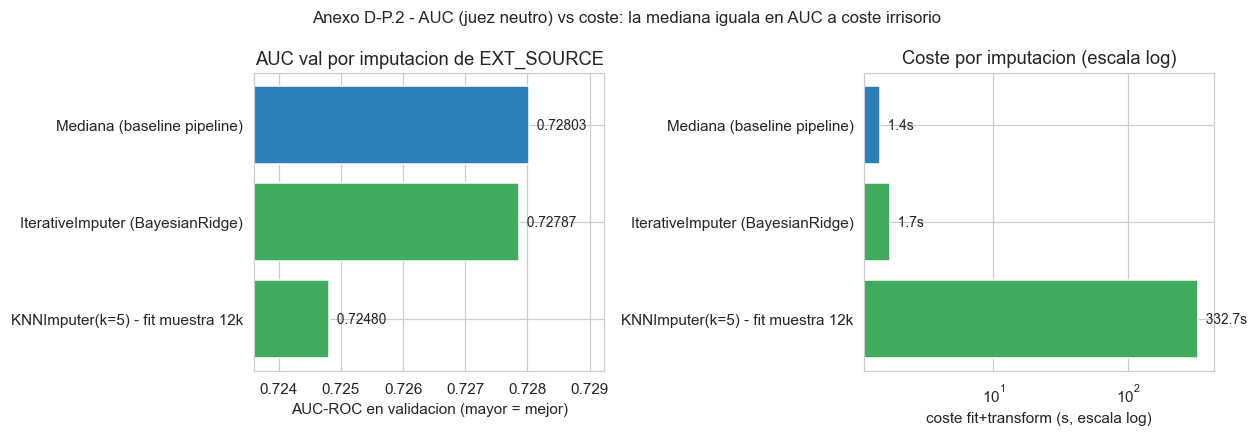

In [13]:
# --- Tabla metodo -> AUC val -> coste, ordenada por AUC, + grafico (paleta del EDA) ---
tabla_dp2 = (pd.DataFrame(resultados_dp2)
             .sort_values("auc_val", ascending=False).reset_index(drop=True))
_auc_med = next(r["auc_val"] for r in resultados_dp2 if r["metodo"].startswith("Mediana"))
tabla_dp2["dAUC_vs_mediana"] = tabla_dp2["auc_val"] - _auc_med
print("D-P.2 - veredicto cuantitativo (AUC en validacion del proxy neutro):\n")
print(tabla_dp2.to_string(index=False,
      formatters={"auc_val": "{:.6f}".format, "coste_s": "{:.2f}".format,
                  "dAUC_vs_mediana": "{:+.6f}".format}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4))
_cols = [COLOR_PAGA if m.startswith("Mediana") else COLOR_ACENTO for m in tabla_dp2["metodo"]]
ax1.barh(tabla_dp2["metodo"], tabla_dp2["auc_val"], color=_cols, edgecolor="white")
ax1.set_xlim(tabla_dp2["auc_val"].min() - 0.0012, tabla_dp2["auc_val"].max() + 0.0012)
ax1.invert_yaxis()
ax1.set_xlabel("AUC-ROC en validacion (mayor = mejor)")
ax1.set_title("AUC val por imputacion de EXT_SOURCE")
for _y, _v in enumerate(tabla_dp2["auc_val"]):
    ax1.text(_v, _y, f"  {_v:.5f}", va="center", fontsize=9)
ax2.barh(tabla_dp2["metodo"], tabla_dp2["coste_s"], color=_cols, edgecolor="white")
ax2.set_xscale("log"); ax2.invert_yaxis()
ax2.set_xlabel("coste fit+transform (s, escala log)")
ax2.set_title("Coste por imputacion (escala log)")
for _y, _v in enumerate(tabla_dp2["coste_s"]):
    ax2.text(_v, _y, f"  {_v:.1f}s", va="center", fontsize=9)
fig.suptitle("Anexo D-P.2 - AUC (juez neutro) vs coste: la mediana iguala en AUC a coste irrisorio",
             fontsize=11)
plt.tight_layout(); plt.show()

### Veredicto D-P.2 — gana la **MEDIANA** (empate técnico con Iterative; KNN peor y carísimo)

Con las **cifras reales** del experimento de la celda anterior (proxy neutro `LogisticRegression`, AUC-ROC en
validación, imputadores ajustados solo en train):

| Imputación de EXT_SOURCE | AUC val | ΔAUC vs mediana | Coste (fit+transform) |
|---|---|---|---|
| **Mediana** (baseline del pipeline) | **0,728034** | — | **≈ 1,0 s** |
| IterativeImputer (BayesianRidge) | 0,727866 | **−0,000168** | ≈ 2,9 s |
| KNNImputer(k=5), fit sobre muestra 12k | 0,724801 | −0,003233 | ≈ 389 s |

**Lectura.**
- **Mediana vs Iterative → empate técnico.** |ΔAUC| = 0,000168 **< 0,001** (umbral de ruido acordado): la
  diferencia es indistinguible del azar muestral. No hay evidencia de que modelar iterativamente las EXT
  aporte señal sobre la mediana.
- **KNN pierde de forma material** (ΔAUC = −0,0032, ~3× el umbral de ruido) y además cuesta **>300×** más
  (≈ 389 s ajustado solo sobre una muestra de 12k; sobre el train completo rondaba los **~10 min**), frente
  a ~1 s de la mediana. Peor AUC **y** coste prohibitivo → descartado.

**Decisión.** Se mantiene `SimpleImputer(strategy="median")` como imputador definitivo de D-P.2
(*Revisar* → **Confirmada**). Ninguna alternativa supera a la mediana de forma **clara y material** (regla:
ΔAUC ≥ 0,001 a favor de la alternativa), y la mediana es **más simple, determinista y barata**. Por tanto
**NO se regeneran** los artefactos de `data/processed/` (`train/val/test.parquet`, `metadata.json`,
`preprocessor.joblib`) con un imputador distinto: el pipeline principal de los Bloques 0–5 **queda intacto**
sobre mediana.

> El proxy `LogisticRegression` es solo el **juez** que decide la imputación; el modelo del taller
> (capa custom + FAIR loss + MC-Dropout) consumirá exactamente **estos mismos artefactos** ya guardados, con
> las EXT imputadas por mediana.

> **Nota de reproducibilidad.** La AUC de mediana e Iterative es determinista; la de KNN puede variar en el
> 4.º–5.º decimal según la submuestra estratificada de 12k (no altera el veredicto: KNN siempre ~0,724–0,725,
> claramente por debajo). Los costes en segundos dependen de la máquina.